# Code to explore the effects of interractions among parameters and make Figure 10 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
dir = 'Data/'
f = open(dir+"Sobol_E1.pkl", "rb")
mySobolResultsPCE = pickle.load(f)
f.close()

In [3]:
f = open(dir+"Sobol_E2.pkl", "rb")
mySobolResultsPCE_E2 = pickle.load(f)
f.close()

In [4]:
f = open(dir+"Sobol_E3.pkl", "rb")
mySobolResultsPCE_E3 = pickle.load(f)
f.close()

In [5]:
f = open(dir+"Sobol_E4.pkl", "rb")
mySobolResultsPCE_E4 = pickle.load(f)
f.close()

In [6]:
f = open(dir+"Sobol_E5.pkl", "rb")
mySobolResultsPCE_E5 = pickle.load(f)
f.close()

In [7]:
batlow10 = [(1,25,89), (16,  63,  96), (28,  90,  98), (60, 109,  86), (104, 123,  62), (157, 137,  43), (210, 147,  67), (248, 161, 123), (253, 183, 188), (250, 204, 250)]
batlow10_2 = []

for t in batlow10:
    r = t[0]/255
    g = t[1]/255
    b = t[2]/255
    batlow10_2.append((r,g,b))

linestyles = ['dashed', 'solid', 'dotted', 'dashdot', (0,(5,1))]

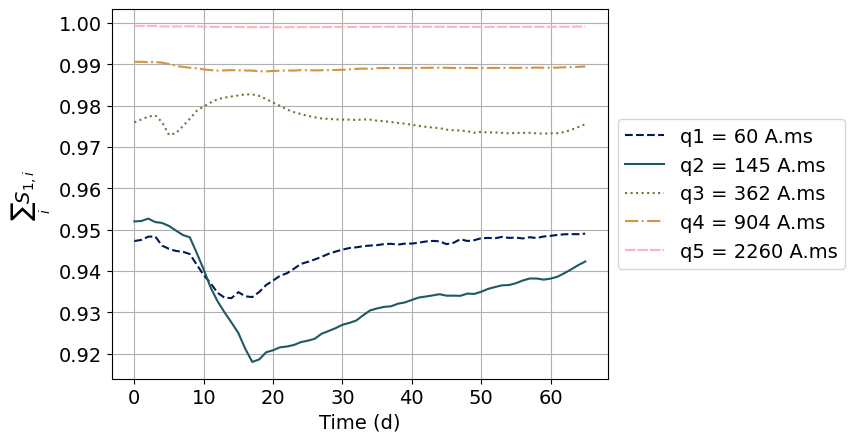

In [8]:
fs = 14

Nsim = len(mySobolResultsPCE['FirstOrder'][0])
S1_l = [np.array(mySobolResultsPCE['FirstOrder']), np.array(mySobolResultsPCE_E2['FirstOrder']), np.array(mySobolResultsPCE_E3['FirstOrder']), 
        np.array(mySobolResultsPCE_E4['FirstOrder']), np.array(mySobolResultsPCE_E5['FirstOrder'])]

sum_S1_L = []

for i in range(len(S1_l)):
    sum_S1_temp = np.zeros(Nsim)
    for j in range(Nsim):
        sum_S1_temp[j] = np.sum(S1_l[i][:,j])
    sum_S1_L.append(sum_S1_temp)

labels = ['q1 = 60 A.ms', 'q2 = 145 A.ms', 'q3 = 362 A.ms',
           'q4 = 904 A.ms', 'q5 = 2260 A.ms']

plt.figure()
for i in range(len(S1_l)):
    plt.plot(sum_S1_L[i], label = labels[i], color = batlow10_2[2*i], linestyle = linestyles[i])
plt.grid()
plt.ylabel('$\sum_i S_{1,i}$', fontsize = fs)
plt.xlabel('Time (d)', fontsize = fs)
plt.legend(loc = 'center left', bbox_to_anchor=(1, 0.5), fontsize = fs)
plt.xticks(fontsize = fs)
plt.yticks(fontsize = fs)
plt.savefig('Figures/Sob_tot/Sum_S1_allQ_bat.jpg', format = 'png', dpi =300, bbox_inches='tight')

In [9]:
Sob_2 = np.array(mySobolResultsPCE_E2['AllOrders'][1])

In [10]:
Sob_2.shape

(153, 66)

In [11]:
np.max(Sob_2)

0.021236921566345768